# 05 — Full Clustering Model Benchmark

## Research objective

This notebook reviews the Stage 5 benchmark and explains why the final primary model is K-Means with four clusters.

The model input is the five-component PCA representation created by Stage 4. Original motion features are used only to interpret and validate the resulting clusters.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLES = PROJECT_ROOT / "outputs" / "tables"
PROCESSED = PROJECT_ROOT / "data" / "processed"

benchmark = pd.read_csv(TABLES / "stage5_model_benchmark.csv")
decision = pd.read_csv(TABLES / "stage5_model_decision_matrix.csv")
sizes = pd.read_csv(TABLES / "stage5_final_cluster_sizes.csv")
profiles = pd.read_csv(TABLES / "stage5_cluster_profile_medians.csv")
stability = pd.read_csv(TABLES / "stage5_kmeans_stability_summary.csv")
assignments = pd.read_csv(PROCESSED / "stage5_final_cluster_assignments.csv")
config = json.loads((TABLES / "stage5_selected_model_config.json").read_text())

print(f"Final trajectories: {len(assignments):,}")
print(f"Selected model: {config['selected_model']}")
print(f"Selected k: {config['selected_k']}")
print(f"Coverage: {config['coverage']*100:.2f}%")

Final trajectories: 19,948
Selected model: KMeans
Selected k: 4
Coverage: 100.00%


## 1. Model families

Full-data sweeps were run for K-Means, MiniBatch K-Means, and Gaussian Mixture Models.

Ward Agglomerative, DBSCAN, and HDBSCAN were screened on city-stratified samples because their computational properties make a full 19,948-row sweep less practical. The sample status is preserved in all result names and decision tables.

In [2]:
benchmark.groupby("model_family").agg(
    configurations=("config_name", "count"),
    best_silhouette=("silhouette", "max"),
    best_coverage=("coverage", "max"),
    minimum_noise=("noise_percentage", "min"),
)

,configurations,best_silhouette,best_coverage,minimum_noise
model_family,,,,
AgglomerativeSample,5,0.565241,1.000000,0.000000
DBSCAN_Sample,9,0.646146,0.996286,0.371429
GaussianMixture,5,0.389104,1.000000,0.000000
HDBSCAN_Sample,6,0.463367,0.603714,39.628571
KMeans,7,0.483710,1.000000,0.000000
MiniBatchKMeans,7,0.286209,1.000000,0.000000


## 2. K-Means number-of-clusters sweep

K = 2 has the strongest compactness, but it represents only a broad two-way split. K = 4 and k = 5 provide richer behavioral separation and are therefore tested more thoroughly for stability.

In [3]:
kmeans = benchmark.loc[benchmark["model_family"].eq("KMeans")].sort_values("n_clusters")
kmeans[[
    "config_name",
    "n_clusters",
    "silhouette",
    "davies_bouldin",
    "smallest_cluster_percentage",
    "cluster_entropy",
    "mean_feature_eta_squared",
]]

,config_name,n_clusters,silhouette,davies_bouldin,smallest_cluster_percentage,cluster_entropy,mean_feature_eta_squared
0,kmeans_k2,2,0.483710,0.977084,9.940846,0.467118,0.140059
1,kmeans_k3,3,0.285811,1.223871,9.379386,0.839441,0.366319
2,kmeans_k4,4,0.286223,1.276209,6.341488,0.894168,0.417506
3,kmeans_k5,5,0.283124,1.167680,5.449168,0.910422,0.451986
4,kmeans_k6,6,0.265175,1.185914,4.817526,0.911063,0.477148
5,kmeans_k7,7,0.234196,1.238448,4.606978,0.955469,0.516241
6,kmeans_k8,8,0.237451,1.223022,2.000201,0.916599,0.541899


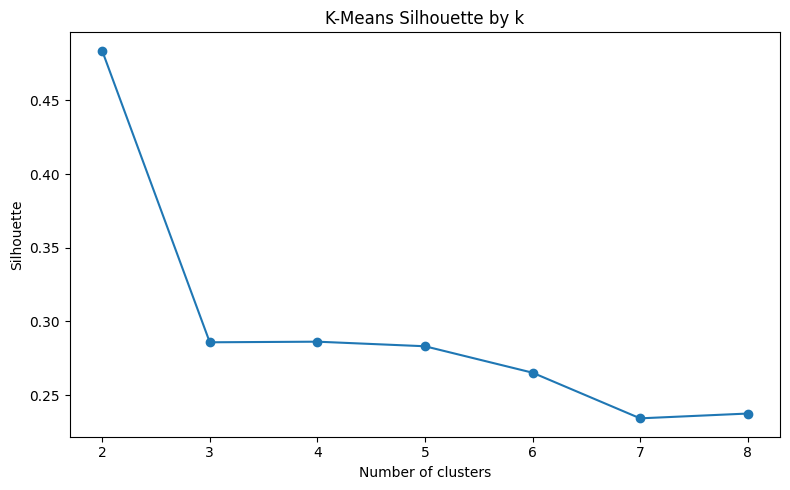

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kmeans["n_clusters"], kmeans["silhouette"], marker="o")
ax.set_title("K-Means Silhouette by k")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette")
ax.set_xticks(kmeans["n_clusters"])
plt.tight_layout()
plt.show()

## 3. Stability evidence

Three different stability ideas are used:

- **Seed stability:** sensitivity to K-Means initialization.
- **Bootstrap stability:** sensitivity to trajectory resampling.
- **Recording and city omission:** sensitivity to changes in the real data collection groups.

The final choice is not based only on random-seed stability.

In [5]:
stability

,config_name,model_family,k,seed_pairwise_ari_mean,seed_pairwise_ari_min,bootstrap_ari_mean,bootstrap_ari_min,bootstrap_smallest_cluster_percentage_min,leave_one_city_out_ari_mean,leave_one_city_out_ari_min,held_out_city_min_cluster_percentage_min,all_clusters_present_each_city,recording_subsample_ari_mean,recording_subsample_ari_min
0,kmeans_k2,KMeans,2,1.000000,1.000000,0.987720,0.979381,9.640064,0.943950,0.880638,4.045643,True,0.626958,0.035219
1,kmeans_k4,KMeans,4,0.681404,0.539259,0.884668,0.804689,6.115901,0.826462,0.567325,1.763485,True,0.920778,0.836819
2,kmeans_k5,KMeans,5,0.710377,0.631815,0.686986,0.638387,5.434129,0.712876,0.629133,1.452282,True,0.740257,0.664300


### Interpretation

K = 2 is very stable under seeds and ordinary bootstrap samples, but it is much less stable when whole recordings are omitted. K = 5 produces more detailed separation but is less stable across nearly every test. K = 4 gives the strongest balance between detail and group-level robustness.

## 4. Final model decision matrix

In [6]:
decision[[
    "candidate",
    "decision",
    "coverage",
    "silhouette",
    "davies_bouldin",
    "smallest_cluster_percentage",
    "reason",
]]

,candidate,decision,coverage,silhouette,davies_bouldin,smallest_cluster_percentage,reason
0,"K-Means, k=2",Not selected,1.000000,0.483710,0.977084,9.940846,Best compactness but too coarse; recording-gro...
1,"K-Means, k=4",Selected primary model,1.000000,0.286223,1.276209,6.341488,"Best balance of full coverage, production seed..."
2,"K-Means, k=5",Sensitivity candidate,1.000000,0.283124,1.167680,5.449168,"Higher feature separation but lower bootstrap,..."
3,"MiniBatch K-Means, k=4",Not selected,1.000000,0.277668,1.306438,7.950672,Similar structure but slightly weaker internal...
4,"Gaussian Mixture, k=4",Not selected,1.000000,0.228802,1.645944,10.432124,"Flexible probabilistic model, but substantiall..."
5,"Agglomerative, k=4 (sample)",Exploratory only,1.000000,0.281605,1.287983,5.850000,"Interpretable sample structure, but full 19,94..."
6,DBSCAN (sample best compactness),Complementary only,0.888286,0.646146,0.342760,0.371429,High sample silhouette but one cluster is belo...
7,HDBSCAN (sample),Complementary only,0.603714,0.384456,1.061942,24.771429,Finds a broad density structure but leaves 39....


## 5. Final behavioral-profile sizes

In [7]:
sizes

,profile_id,profile_name,trajectory_count,percentage
0,1,Smooth and Steady,7477,37.482454
1,2,Stop-and-Go,6866,34.419491
2,3,Dynamic Speed Adjustment,4338,21.746541
3,4,Acceleration-Intensive,1267,6.351514


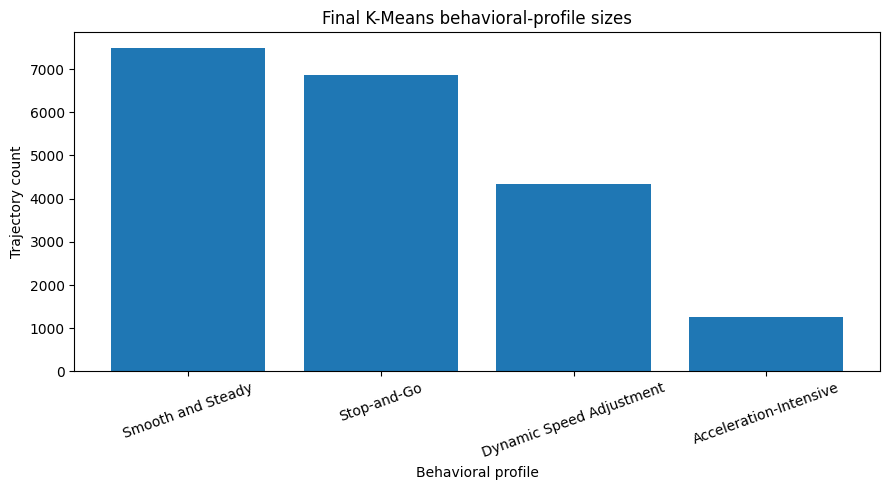

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(sizes["profile_name"], sizes["trajectory_count"])
ax.set_title("Final K-Means behavioral-profile sizes")
ax.set_xlabel("Behavioral profile")
ax.set_ylabel("Trajectory count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 6. Original-feature interpretation

Cluster labels are assigned after reviewing the medians of the original ten trajectory features. The names are descriptive summaries, not ground-truth classes.

In [9]:
profiles

,profile_id,profile_name,mean_speed_mps,max_speed_mps,speed_std_mps,mean_long_acc_mps2,max_acceleration_mps2,max_deceleration_mps2,acceleration_std_mps2,mean_abs_jerk_mps3,observed_stop_transition_count,stopped_time_ratio
0,1,Smooth and Steady,6.727166,9.368795,1.195745,0.151793,0.993201,0.799482,0.489474,0.436295,0.0,0.000000
1,2,Stop-and-Go,2.081679,9.882946,2.928115,0.077738,1.789831,1.721508,0.649127,0.360635,1.0,0.590874
2,3,Dynamic Speed Adjustment,6.625349,10.863837,2.097874,0.246765,1.955210,1.926502,0.967754,0.780429,0.0,0.000000
3,4,Acceleration-Intensive,6.706837,10.704903,1.910059,0.358235,6.843118,2.184274,1.529067,1.111171,0.0,0.000000


### Profile meanings

- **Smooth and Steady:** lowest motion variability, acceleration, braking, and jerk.
- **Stop-and-Go:** low mean speed, high speed variation, observed stopping, and a large stopped-time ratio.
- **Dynamic Speed Adjustment:** moderate acceleration, braking, speed variability, and jerk while generally remaining in motion.
- **Acceleration-Intensive:** very high maximum acceleration, acceleration variation, and jerk.


## 7. City composition

Every profile appears in every city. This reduces the risk that a profile is merely a city identifier, but differences in city proportions still require formal cross-city validation.

In [10]:
city_percentages = pd.read_csv(TABLES / "stage5_cluster_city_percentages.csv")
city_percentages

,profile_id,profile_name,Changchun,Chongqing,Tianjin,Xi'an
0,1,Smooth and Steady,31.068610,10.565735,33.796977,24.568677
1,2,Stop-and-Go,47.960967,12.350714,16.414215,23.274104
2,3,Dynamic Speed Adjustment,54.956201,5.832181,14.591978,24.619640
3,4,Acceleration-Intensive,52.486188,2.920284,19.415943,25.177585


## 8. Tianjin metadata interpretation

Crossing type and signal-violation behavior are examined only after clustering. They were not used to create the clusters.

In [11]:
tianjin_cross = pd.read_csv(TABLES / "stage5_tianjin_crosstype_percentages.csv")
tianjin_violation = pd.read_csv(TABLES / "stage5_tianjin_violation_percentages.csv")
print("Crossing type percentages")
display(tianjin_cross)
print("Signal-violation percentages")
display(tianjin_violation)

Crossing type percentages


,profile_id,profile_name,LeftTurn,Others,RightTurn,StraightCross
0,1,Smooth and Steady,21.764939,0.791452,36.129798,41.313811
1,2,Stop-and-Go,25.643301,2.928128,4.968944,66.459627
2,3,Dynamic Speed Adjustment,27.172196,0.631912,34.913112,37.282780
3,4,Acceleration-Intensive,14.634146,0.813008,30.081301,54.471545


Signal-violation percentages


,profile_id,profile_name,No violation of traffic lights,red-light running,yellow-light running
0,1,Smooth and Steady,96.398892,0.554017,3.047091
1,2,Stop-and-Go,99.023957,0.887311,0.088731
2,3,Dynamic Speed Adjustment,95.892575,0.789889,3.317536
3,4,Acceleration-Intensive,95.934959,0.406504,3.658537


## Notebook conclusion

The final primary partition is **K-Means with four clusters**, fitted with `n_init=50` on the five Stage 4 PCA components.

The four final profiles are:

1. Smooth and Steady
2. Stop-and-Go
3. Dynamic Speed Adjustment
4. Acceleration-Intensive

The final partition covers all 19,948 valid passenger-car trajectories. Stage 6 must validate whether the profile meanings remain consistent across recordings and held-out cities.